# Telco Customer Churn – Exploratory Data Analysis

## Objective
The objective of this analysis is to explore customer demographics, service usage, and billing information 
to identify patterns associated with customer churn. The insights derived from this exploratory analysis 
will later inform feature engineering and predictive modeling aimed at proactively identifying customers 
at risk of churn.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import missingno as msno

import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8")

missing_tokens = ['', ' ', 'NA', 'N/A', 'na', 'null', 'NULL']

In [2]:
data_path = r"data\WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [3]:
df = pd.read_csv(data_path)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.describe(include = 'all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


## Dataset Overview

The dataset contains 7,043 customer records with 21 features capturing demographic details, 
service subscriptions, contract information, and billing behavior. The target variable, 
`Churn`, indicates whether a customer has discontinued the service.

Most features are categorical, reflecting service usage and customer attributes. 
While the dataset shows no explicit missing values, certain columns (notably billing-related fields) 
exhibit data type inconsistencies that require further inspection before modeling.


In [9]:
print(df['Churn'].value_counts())
df['Churn'].value_counts(normalize=True)


Churn
No     5174
Yes    1869
Name: count, dtype: int64


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

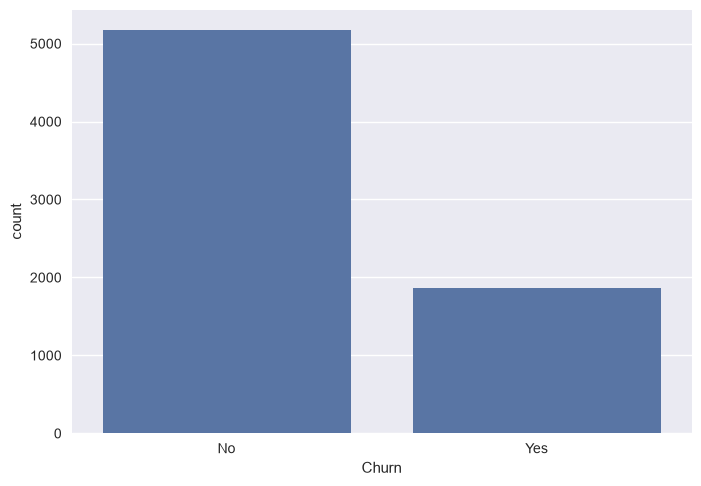

In [10]:
sns.countplot(x = 'Churn', data = df)

In [11]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(exclude='object').columns
categorical_cols, numerical_cols

(Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
        'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
        'Churn'],
       dtype='str'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str'))

## Feature Overview

The dataset includes demographic variables (e.g., `gender`, `SeniorCitizen`, `Partner`), 
service-related features (such as `InternetService`, `TechSupport`, and streaming services), 
contract and payment information (`Contract`, `PaymentMethod`), and billing variables 
(`MonthlyCharges`, `TotalCharges`).

While `SeniorCitizen` is stored as a numeric variable, it represents a binary categorical attribute. 
Additionally, `TotalCharges` is stored as a string despite representing continuous monetary values, 
indicating a data type inconsistency that requires further inspection.


In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
for col in categorical_cols:
    count = df[col].isin(missing_tokens).sum()
    if(count>0):
        print(f'{col} : {count}')

TotalCharges : 11


## Data Quality Check

Standard null checks show no missing values; however, 11 empty string entries are present in the 
`TotalCharges` column. These may correspond to customers with zero tenure and indicate a data type 
inconsistency that must be handled before numerical analysis.


In [14]:
df[df['TotalCharges'] == ' '][['tenure', 'MonthlyCharges', 'Churn']]


,tenure,MonthlyCharges,Churn
488,0,52.55,No
753,0,20.25,No
936,0,80.85,No
1082,0,25.75,No
1340,0,56.05,No
3331,0,19.85,No
3826,0,25.35,No
4380,0,20.00,No
5218,0,19.70,No
6670,0,73.35,No


## Handling Missing `TotalCharges`

The 11 rows with missing `TotalCharges` correspond to customers with zero tenure and no recorded churn. 
As these represent newly onboarded customers with no accumulated billing and constitute a negligible 
portion of the dataset, they are removed to ensure consistency in numerical analysis.


In [15]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

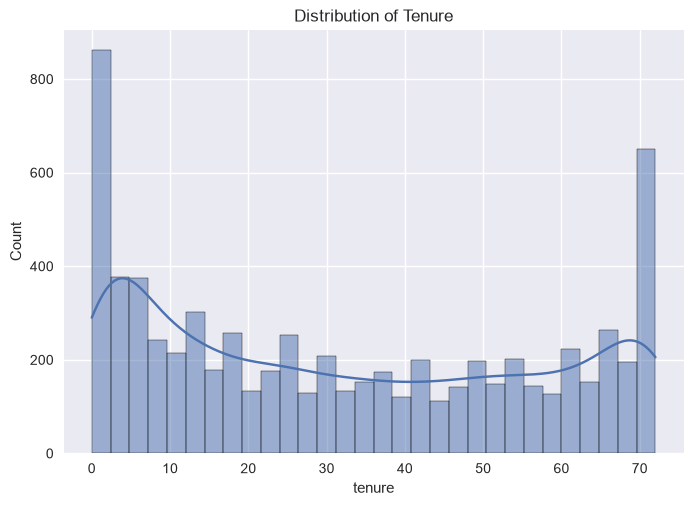

In [16]:
sns.histplot(df['tenure'], kde = True, bins = 30)
plt.title("Distribution of Tenure")
plt.show()

In [17]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


<Axes: xlabel='Churn', ylabel='tenure'>

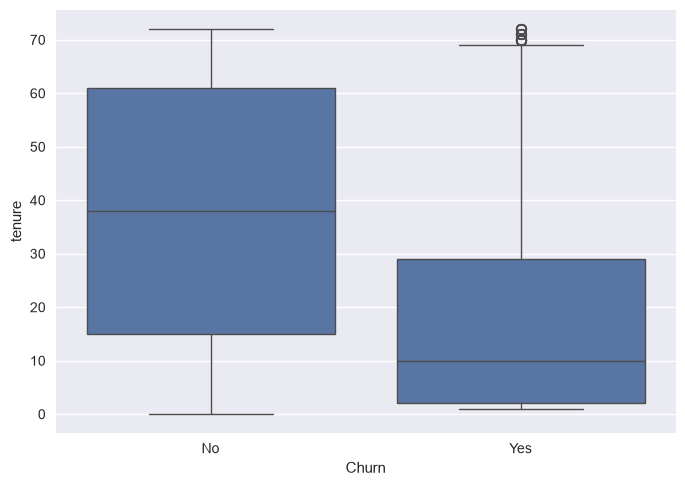

In [18]:
import seaborn as sns
sns.boxplot(x='Churn', y='tenure', data=df)


## Tenure vs Churn

Churned customers exhibit substantially shorter tenure than non-churned customers, with a median tenure of 10 months compared to 38 months.
This indicates that churn risk is highest early in the customer lifecycle, while long-tenured customers are more likely to remain with the service.


In [19]:
df['MonthlyCharges'].describe()


count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

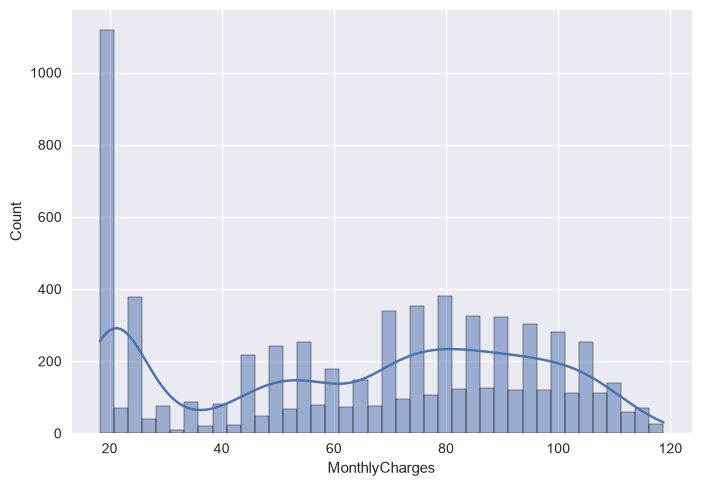

In [20]:
sns.histplot(df['MonthlyCharges'], bins=40, kde=True)
plt.show()

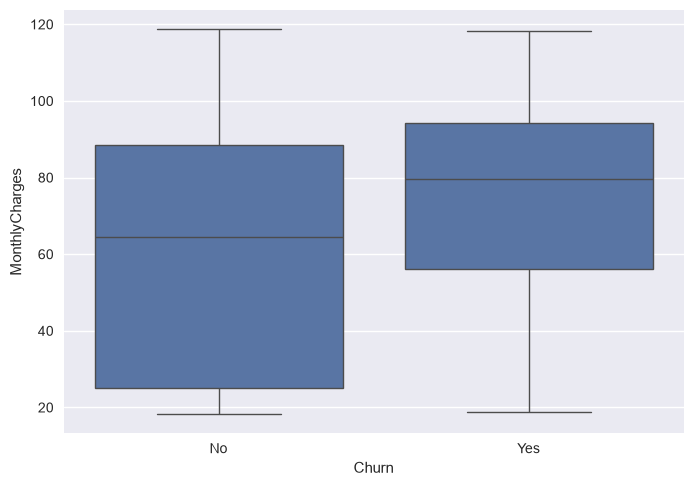

In [21]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

## Monthly Charges vs Churn

Churned customers tend to have higher monthly charges, with a higher median and upper quartile compared to non-churned customers.
While low-cost plans show a strong concentration of customers, higher monthly charges are associated with increased churn risk, though price alone does not fully separate churn behavior.


<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

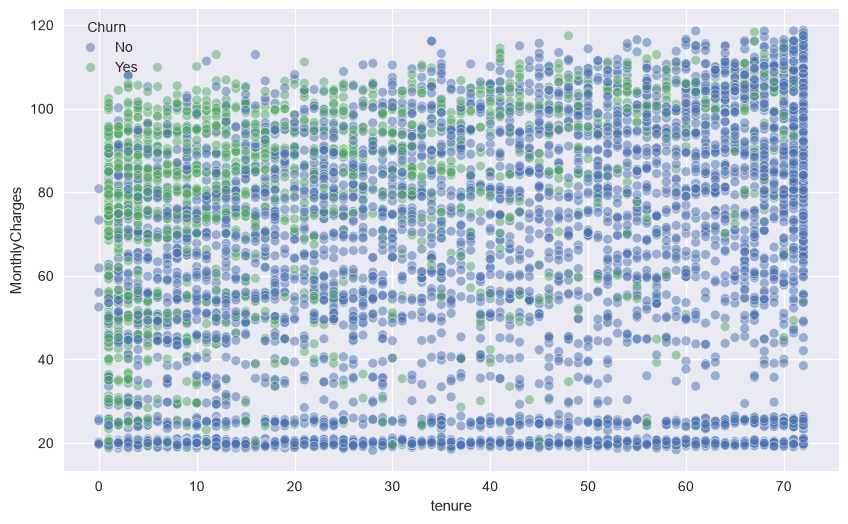

In [22]:
plt.figure(figsize = (10,6))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df, alpha=0.5)

In [23]:
tenure_bins = pd.cut(df['tenure'], bins=[0, 3, 6, 12, 24, 48, 72])

df.groupby(tenure_bins)['Churn'].value_counts(normalize=True)

tenure    Churn
(0, 3]    Yes      0.568030
          No       0.431970
(3, 6]    No       0.553699
          Yes      0.446301
(6, 12]   No       0.641135
          Yes      0.358865
(12, 24]  No       0.712891
          Yes      0.287109
(24, 48]  No       0.796110
          Yes      0.203890
(48, 72]  No       0.904868
          Yes      0.095132
Name: proportion, dtype: float64

## Tenure-Based Churn Pattern

Churn rates decline sharply with increasing tenure, exceeding 50% in the first 3 months and falling below 10% after 4 years.
This confirms that churn risk is concentrated early in the customer lifecycle.


In [24]:
df.groupby('Contract')['Churn'].value_counts(normalize = True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

## Contract Type vs Churn

Churn decreases sharply with longer contract duration. Month-to-month customers exhibit the highest churn, while two-year contract customers show minimal churn, indicating strong lock-in effects.


In [25]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

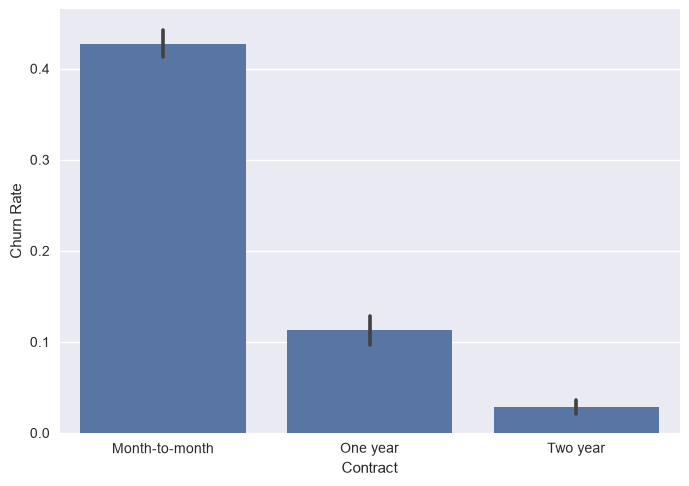

In [26]:
# This is just for visuals, we already did it...
df['Churn_num'] = df['Churn'].map({'No': 0, 'Yes': 1})

sns.barplot(x='Contract', y='Churn_num', data=df)
plt.ylabel('Churn Rate')
plt.show()


In [27]:
df.groupby('InternetService')['Churn'].value_counts(normalize=True)


InternetService  Churn
DSL              No       0.810409
                 Yes      0.189591
Fiber optic      No       0.581072
                 Yes      0.418928
No               No       0.925950
                 Yes      0.074050
Name: proportion, dtype: float64

<Axes: xlabel='InternetService', ylabel='Churn_num'>

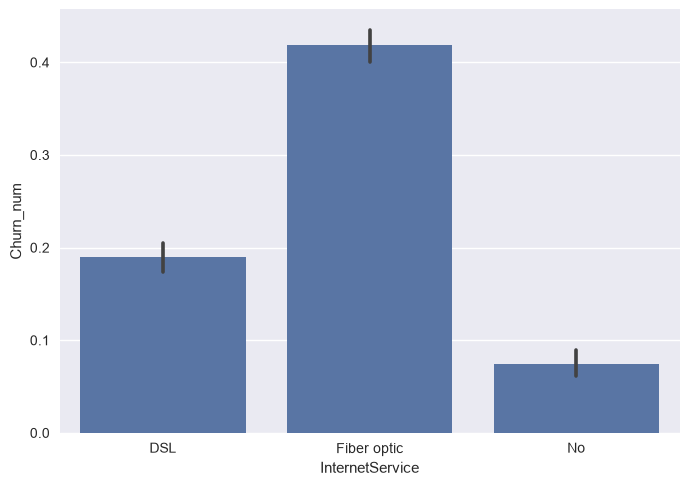

In [28]:
sns.barplot(x = 'InternetService', y = 'Churn_num', data = df)

## Internet Service vs Churn

Fiber optic customers exhibit significantly higher churn (42%) compared to DSL (19%) and customers without internet service (7%), indicating that higher-end internet plans are associated with greater churn risk.


In [29]:
df.groupby('OnlineSecurity')['Churn'].value_counts(normalize=True)


OnlineSecurity       Churn
No                   No       0.582333
                     Yes      0.417667
No internet service  No       0.925950
                     Yes      0.074050
Yes                  No       0.853888
                     Yes      0.146112
Name: proportion, dtype: float64

<Axes: xlabel='OnlineSecurity', ylabel='Churn_num'>

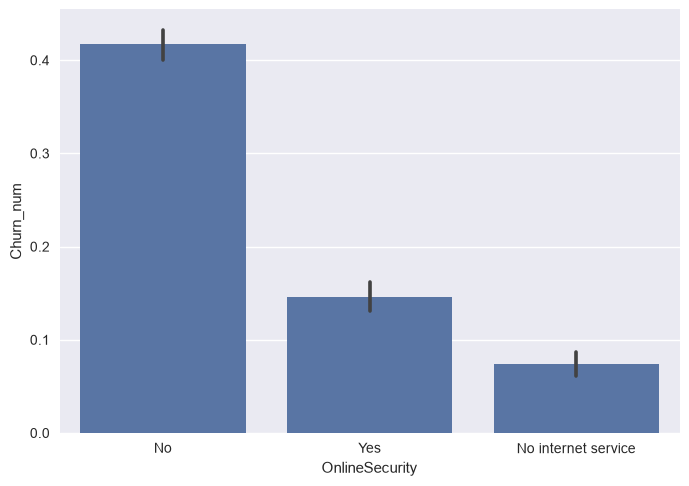

In [30]:
sns.barplot(x = 'OnlineSecurity', y = 'Churn_num', data = df)

## Online Security vs Churn

Customers without online security exhibit significantly higher churn (42%) compared to those with security enabled (15%). This may suggest that value-added protection services play a strong role in customer retention.


In [31]:
df.groupby('TechSupport')['Churn'].value_counts(normalize=True)


TechSupport          Churn
No                   No       0.583645
                     Yes      0.416355
No internet service  No       0.925950
                     Yes      0.074050
Yes                  No       0.848337
                     Yes      0.151663
Name: proportion, dtype: float64

<Axes: xlabel='TechSupport', ylabel='Churn_num'>

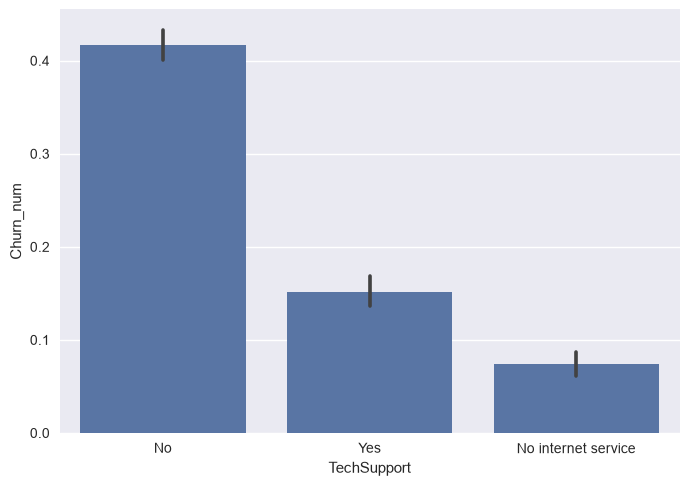

In [32]:
sns.barplot(x = 'TechSupport', y = 'Churn_num', data = df)

## Technical Support vs Churn

Customers without technical support exhibit substantially higher churn (~42%) compared to those with access to support (~15%), indicating a strong association between availability of support services and customer retention.


In [33]:
df[df['InternetService'] != 'No'].groupby('TechSupport')['Churn'].value_counts(normalize=True)


TechSupport  Churn
No           No       0.583645
             Yes      0.416355
Yes          No       0.848337
             Yes      0.151663
Name: proportion, dtype: float64

In [34]:
df.groupby('StreamingTV')['Churn'].value_counts(normalize=True)


StreamingTV          Churn
No                   No       0.664769
                     Yes      0.335231
No internet service  No       0.925950
                     Yes      0.074050
Yes                  No       0.699298
                     Yes      0.300702
Name: proportion, dtype: float64

## Streaming TV vs Churn

Streaming TV shows only a weak association with churn, with similar churn rates for customers with and without the service. This suggests that entertainment add-ons alone do not significantly influence retention.


In [35]:
df.groupby('StreamingMovies')['Churn'].value_counts(normalize=True)


StreamingMovies      Churn
No                   No       0.663196
                     Yes      0.336804
No internet service  No       0.925950
                     Yes      0.074050
Yes                  No       0.700586
                     Yes      0.299414
Name: proportion, dtype: float64

## Streaming Movies vs Churn

Similar to streaming TV, streaming movies show only a weak association with churn, with marginally lower churn among customers using the service. These entertainment add-ons do not appear to be strong standalone drivers of retention.


In [36]:
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True)


PaymentMethod              Churn
Bank transfer (automatic)  No       0.832902
                           Yes      0.167098
Credit card (automatic)    No       0.847569
                           Yes      0.152431
Electronic check           No       0.547146
                           Yes      0.452854
Mailed check               No       0.808933
                           Yes      0.191067
Name: proportion, dtype: float64

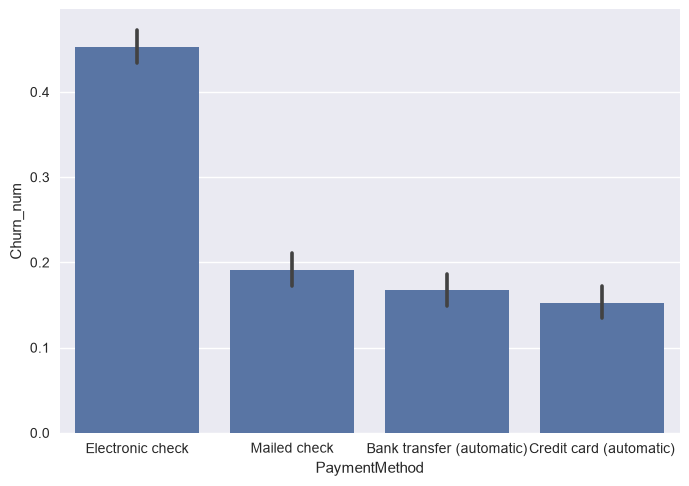

In [37]:
sns.barplot(x = 'PaymentMethod', y = 'Churn_num', data = df)
plt.show()

## Payment Method vs Churn

Customers using electronic checks exhibit the highest churn (45%), while those on automatic payment methods show significantly lower churn (~15–17%). This suggests that payment friction is a strong behavioral indicator of churn risk.


In [38]:
df.groupby('PaperlessBilling')['Churn'].value_counts(normalize=True)


PaperlessBilling  Churn
No                No       0.836699
                  Yes      0.163301
Yes               No       0.664349
                  Yes      0.335651
Name: proportion, dtype: float64

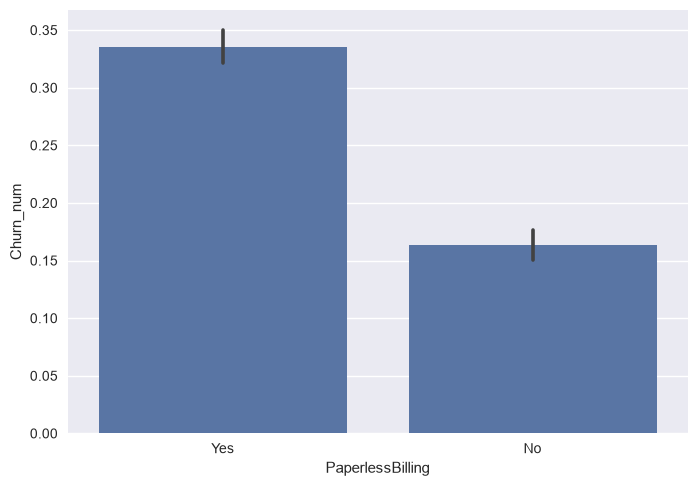

In [39]:
sns.barplot(x = 'PaperlessBilling', y = 'Churn_num', data = df)
plt.show()

## Paperless Billing vs Churn

Customers using paperless billing show substantially higher churn (34%) compared to those receiving paper bills (~16%), suggesting that billing preferences reflect underlying differences in customer commitment and churn risk.


In [40]:
for col in ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'OnlineBackup', 'DeviceProtection']:
    print(col)
    print(df.groupby(col)['Churn'].value_counts(normalize=True))
    print('**************************************************************************************')


gender
gender  Churn
Female  No       0.730791
        Yes      0.269209
Male    No       0.738397
        Yes      0.261603
Name: proportion, dtype: float64
**************************************************************************************
SeniorCitizen
SeniorCitizen  Churn
0              No       0.763938
               Yes      0.236062
1              No       0.583187
               Yes      0.416813
Name: proportion, dtype: float64
**************************************************************************************
Partner
Partner  Churn
No       No       0.670420
         Yes      0.329580
Yes      No       0.803351
         Yes      0.196649
Name: proportion, dtype: float64
**************************************************************************************
Dependents
Dependents  Churn
No          No       0.687209
            Yes      0.312791
Yes         No       0.845498
            Yes      0.154502
Name: proportion, dtype: float64
***********************************

In [41]:
df['PhoneService'].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

## Additional Feature Sweep

Demographic features such as gender show negligible association with churn, while senior citizens exhibit higher churn rates. 
Customers with partners or dependents tend to churn less, indicating greater stability. 
Basic phone services and multiple lines show weak standalone effects. 
Value-added services like online backup and device protection are associated with lower churn, reinforcing the importance of bundled support features.


In [42]:
pd.crosstab(
    df['Contract'],
    df['PaymentMethod'],
    normalize='index'
)


PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,0.152000,0.140129,0.477419,0.230452
One year,0.265445,0.270197,0.235574,0.228785
Two year,0.332743,0.342773,0.099115,0.225369


In [43]:
pd.crosstab(
    [df['Contract'], df['PaymentMethod']],
    df['Churn'],
    normalize='index'
).sort_values(by='Yes', ascending=False)


Churn                                           No       Yes
Contract       PaymentMethod                                
Month-to-month Electronic check           0.462703  0.537297
               Bank transfer (automatic)  0.658744  0.341256
               Credit card (automatic)    0.672192  0.327808
               Mailed check               0.684211  0.315789
One year       Electronic check           0.815562  0.184438
               Credit card (automatic)    0.896985  0.103015
               Bank transfer (automatic)  0.902813  0.097187
Two year       Electronic check           0.922619  0.077381
One year       Mailed check               0.931751  0.068249
Two year       Bank transfer (automatic)  0.966312  0.033688
               Credit card (automatic)    0.977625  0.022375
               Mailed check               0.992147  0.007853

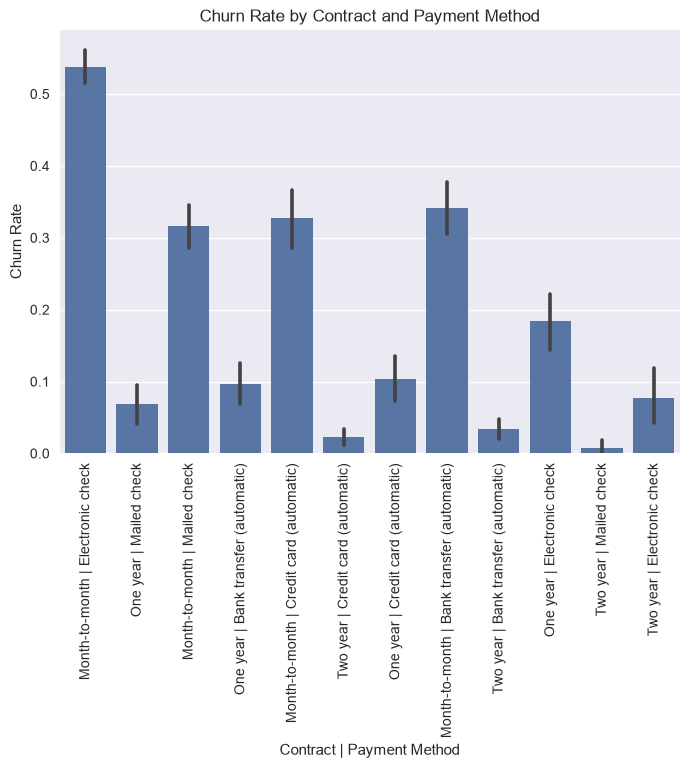

In [44]:
df['Contract_Payment'] = df['Contract'] + ' | ' + df['PaymentMethod']


sns.barplot(
    x='Contract_Payment',
    y='Churn_num',
    data=df,
    estimator='mean'
)

plt.xticks(rotation=90)
plt.ylabel('Churn Rate')
plt.xlabel('Contract | Payment Method')
plt.title('Churn Rate by Contract and Payment Method')
plt.show()


## Contract × Payment Method Interaction

Churn risk is highly concentrated among month-to-month customers using electronic checks, with over 50% churn in this segment. In contrast, long-term contracts combined with automatic payment methods exhibit minimal churn, highlighting the compounding effect of low commitment and payment friction.


In [45]:
pd.crosstab(
    [tenure_bins, df['Contract']],
    df['Churn'],
    normalize='index'
).sort_values(by='Yes', ascending=False)


Churn                          No       Yes
tenure   Contract                          
(0, 3]   Month-to-month  0.419512  0.580488
(3, 6]   Month-to-month  0.523196  0.476804
(6, 12]  Month-to-month  0.580034  0.419966
(12, 24] Month-to-month  0.622795  0.377205
(24, 48] Month-to-month  0.670823  0.329177
(48, 72] Month-to-month  0.739766  0.260234
         One year        0.870662  0.129338
(3, 6]   One year        0.888889  0.111111
(24, 48] One year        0.893822  0.106178
(6, 12]  One year        0.894118  0.105882
(0, 3]   One year        0.900000  0.100000
(12, 24] One year        0.918782  0.081218
(48, 72] Two year        0.966746  0.033254
(24, 48] Two year        0.978102  0.021898
(6, 12]  Two year        1.000000  0.000000
(3, 6]   Two year        1.000000  0.000000
(0, 3]   Two year        1.000000  0.000000
(12, 24] Two year        1.000000  0.000000

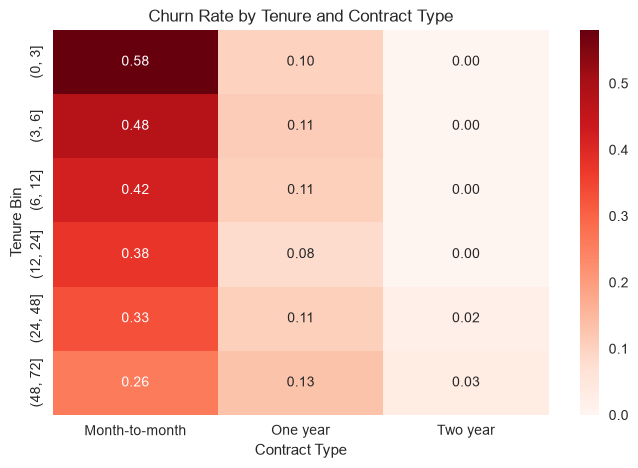

In [46]:
churn_tenure_contract = pd.crosstab(
    tenure_bins,
    df['Contract'],
    values=df['Churn_num'],
    aggfunc='mean'
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    churn_tenure_contract,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)
plt.title('Churn Rate by Tenure and Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Tenure Bin')
plt.show()

## Tenure × Contract Interaction

Churn risk is highest among early-tenure customers on month-to-month contracts, exceeding 50% within the first three months. 
While churn decreases with tenure, month-to-month customers remain vulnerable even at long tenures. 
In contrast, one-year and especially two-year contracts exhibit consistently low churn across all tenure stages, indicating strong commitment effects.


## Key EDA Insights

Customer churn is strongly driven by lifecycle stage, commitment level, service value, and billing behavior. Churn risk is highest during early tenure, particularly within the first 3–6 months, and declines steadily as tenure increases. Contract type exerts a dominant effect: month-to-month customers exhibit substantially higher churn, while two-year contracts show minimal churn across all tenure stages. Payment behavior further amplifies risk, with electronic check users—especially those on month-to-month contracts—forming the highest churn-risk segment. Value-added services such as technical support and online security are associated with significantly lower churn, even after controlling for internet usage. In contrast, entertainment add-ons (streaming services) and basic demographic attributes show weak standalone effects. Overall, churn risk concentrates where low commitment, high friction, and early lifecycle stages intersect.
